In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.decomposition import PCA

import matplotlib.lines as mlines
from sklearn.cluster import KMeans
from collections import Counter

from scipy.stats import chi2_contingency

#für Hierarchisches Clustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("data/ab_ag_annotated.tsv", sep="\t")
regions = ['CDR_H1', 'CDR_H2', 'CDR_L1', 'CDR_L2', 'CDR_L3']
residues = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
antigen_labels = df["antigen_name"].tolist()

['hemagglutinin', 'hemagglutinin', 'hemagglutinin', 'spike glycoprotein', 'neuraminidase', 'spike protein s1', 'spike protein s1', 'spike protein s1', 'spike protein s1', 'spike glycoprotein', 'spike glycoprotein', 'spike glycoprotein', 'spike glycoprotein', 'spike glycoprotein', 'spike glycoprotein', 'neuraminidase', 'neuraminidase', 'spike glycoprotein', 'neuraminidase', 'hemagglutinin', 'spike glycoprotein', 'hemagglutinin', 'hemagglutinin', 'spike glycoprotein', 'spike glycoprotein', 'spike glycoprotein', 'hemagglutinin', 'hemagglutinin', 'hemagglutinin', 'spike protein s1', 'spike protein s1', 'spike protein s1', 'spike protein s1', 'spike protein s1', 'spike protein s1', 'spike glycoprotein', 'spike glycoprotein', 'envelope glycoprotein e2', 'spike glycoprotein', 'spike glycoprotein', 'spike glycoprotein', 'spike glycoprotein', 'spike glycoprotein', 'spike protein s1', 'spike glycoprotein', 'spike glycoprotein', 'envelope glycoprotein gp120', 'envelope glycoprotein gp120', 'envel

In [ ]:
def residue_percentage(sequence, residues):
    """
    Berechnet den prozentualen Anteil jeder Aminosäure in der gegebenen Sequenz und gibt eine Liste seq_residues zurück,
    die jede Aminosäure als Tupel (residue, percentage) enthält.
    sequence: list, die eine CDR-Sequenz repäsentiert, und deren Einträge aus einem String pro Aminosäure besteht, z.B. ['A', 'R', 'N', ...]
    """
    seq_residues = []
    for residue in residues:
        percentage = sequence.count(residue) / len(sequence)
        seq_residues.append((residue, percentage))
    return seq_residues


def show_feature_space(feature_space, CDR_region, antigen_labels):#zusätzliches Argument für color-coding: antigen
    """
    Visualisiert den Feature-Space der CDR-Sequenzen mittels PCA in 3D.
    feature_space: pd.DataFrame, der die PDB-IDs in einer Spalte "pdb" und die prozentualen Anteile der Aminosäuren in den entsprechenden CDR-Sequenzen
    in je einer Spalte pro Aminosäure enthält.
    """
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)
    
    #### Farbzuordnung vorbereiten
    unique_antigens = sorted(list(set(antigen_labels)))
    color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
    color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
    colors = [color_dict[a] for a in antigen_labels]
   

    # Plotten der PCA-Koordinaten in 2D
    fig, (ax_scatter, ax_legend) = plt.subplots(2, 1, figsize=(10,10), gridspec_kw={'height_ratios': [4,1]})
    ax_scatter.scatter(coords[:, 0], coords[:, 1], c=colors, s=20, alpha=0.7)#zusätzliche Argumente für color-coding: c=color_codes, cmap='tab20', 
    ax_scatter.set_xlabel("PCA 1")
    ax_scatter.set_ylabel("PCA 2")
    ax_scatter.set_title(f"PCA of {CDR_region} Sequences")


    # 2. Legende als eigene Figure
    legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Größe anpassen je nach Anzahl Antigene
    legend_ax.axis('off')  # Keine Achsen

    # Erstelle Handles
    handles = [mlines.Line2D([], [], color=color_dict[ant], marker='o', linestyle='None',
                             markersize=8, label=ant)
               for ant in unique_antigens]

    # Erzeuge Legende
    legend = legend_ax.legend(handles=handles, loc='center', ncol=1, fontsize='small')  # ncol=1 → alle untereinander

    legend_fig.tight_layout()
    plt.show()

In [ ]:
'''Kann der Teil in die Funktion show_feature_space eingebaut werden?'''
unique_antigens = sorted(list(set(antigen_labels)))
color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
colors = [color_dict[a] for a in antigen_labels]

# Dictionary, das die Feature-Space DataFrames für jede CDR-Region speichert
feature_spaces = {}
# Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen und zu visualisieren:
for region in regions: 
    # Berechne den prozentualen Anteil jeder Aminosäure in den CDR-Sequenzen und füge sie in den Feature-Space ein.
    fs_rows = [] #um daten vor befüllen des dataframes vorzubereiten damit es nicht so lange dauert
    for i, df_top_row in df_top.iterrows():
        pdb = df_top_row['pdb']
        antigen_name = df_top_row['antigen_name']
        antigen_species = df_top_row['antigen_species']
        seq_as_str = df_top_row[region]
        seq_as_list = list(seq_as_str)

        residues_percentages = residue_percentage(seq_as_list, residues)
        percentages = [pair[1] for pair in residues_percentages]

        seq_length = len(seq_as_list)

        fs_row = [pdb] + [antigen_name] + [antigen_species] + [seq_length] + percentages
        fs_rows.append(fs_row)

    feature_space = pd.DataFrame(fs_rows, columns=["pdb"] + ["antigen_name"] + ["antigen_species"] + ["seq_length"] + residues)
    columns_to_scale = ["seq_length"] + residues
    feature_space_z = feature_space.copy()
    feature_space_z[columns_to_scale] = scaler.fit_transform(feature_space[columns_to_scale])
    feature_spaces[region] = feature_space_z


In [5]:
feature_spaces["CDR_L1"]
any("M" in list(seq) for seq in df_top["CDR_L1"])


False

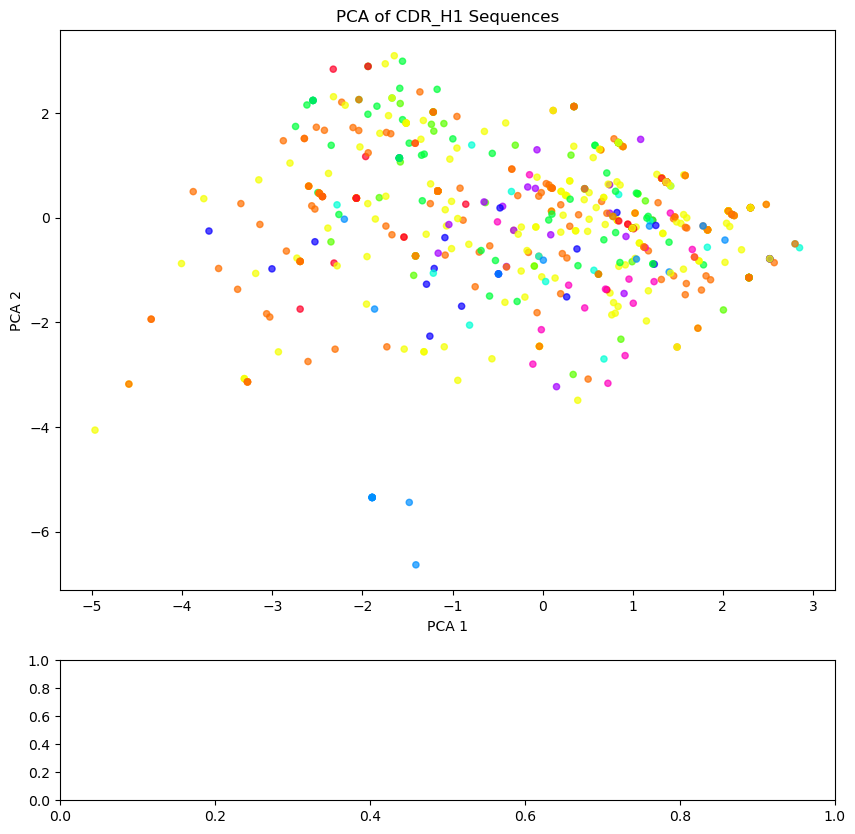

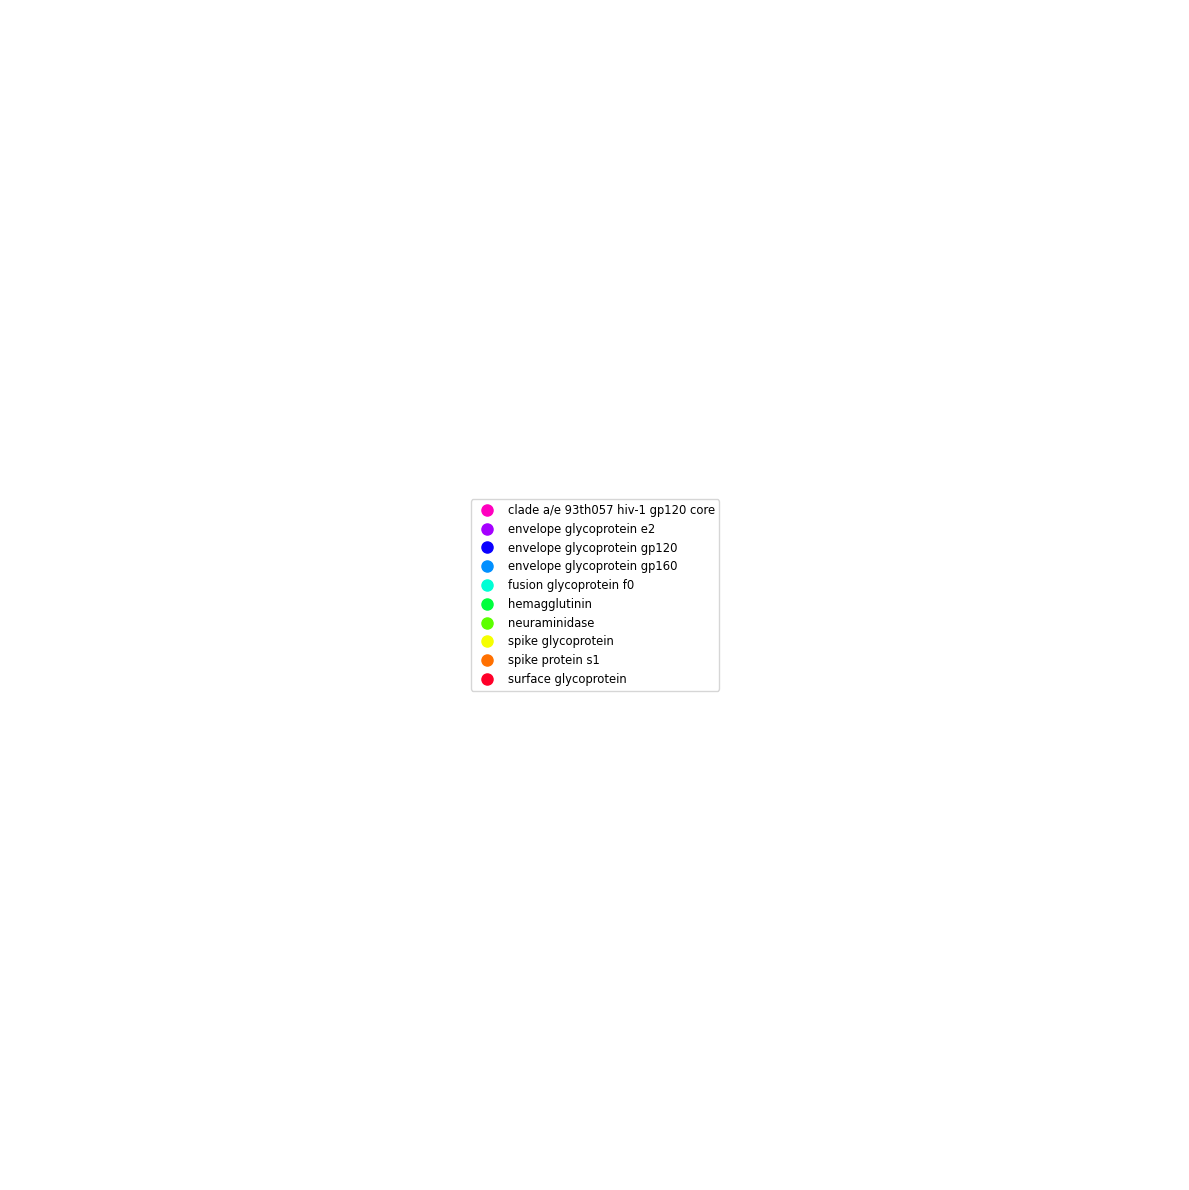

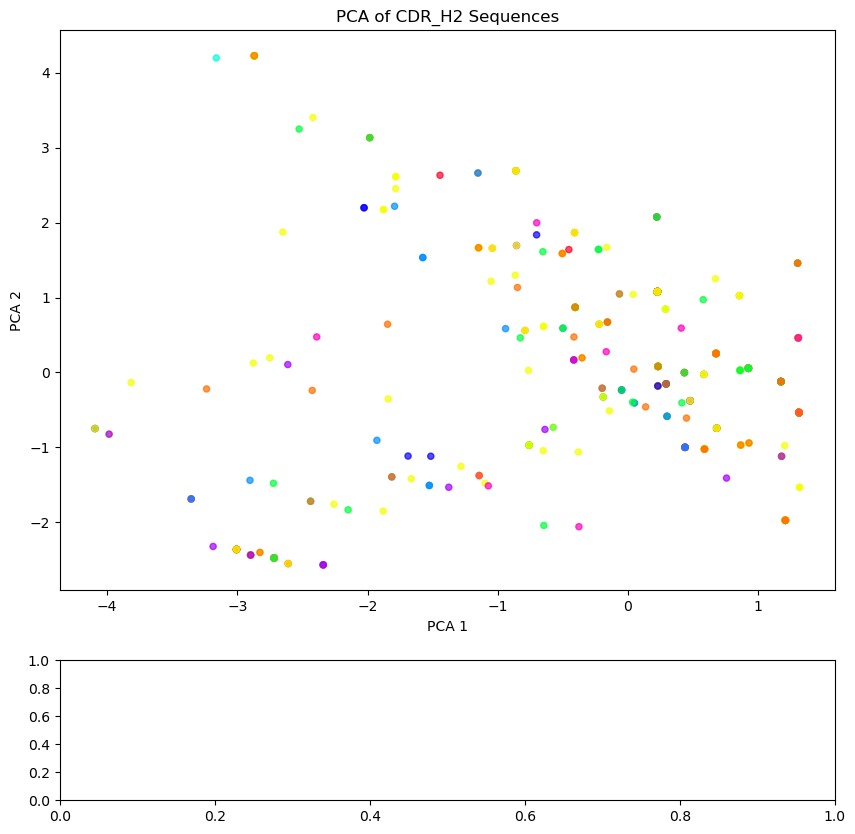

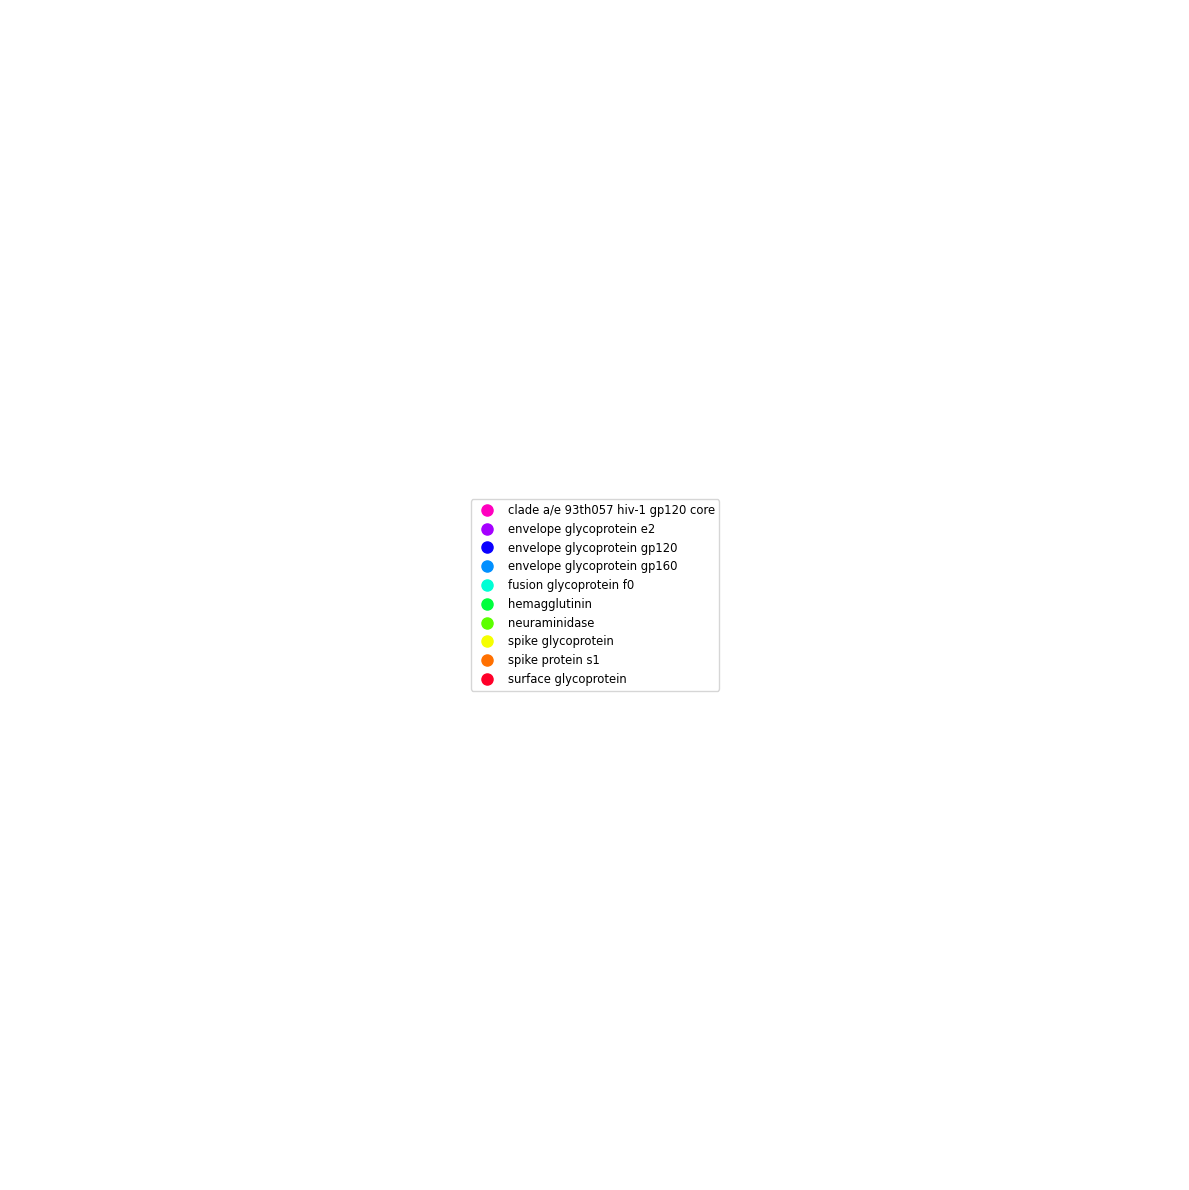

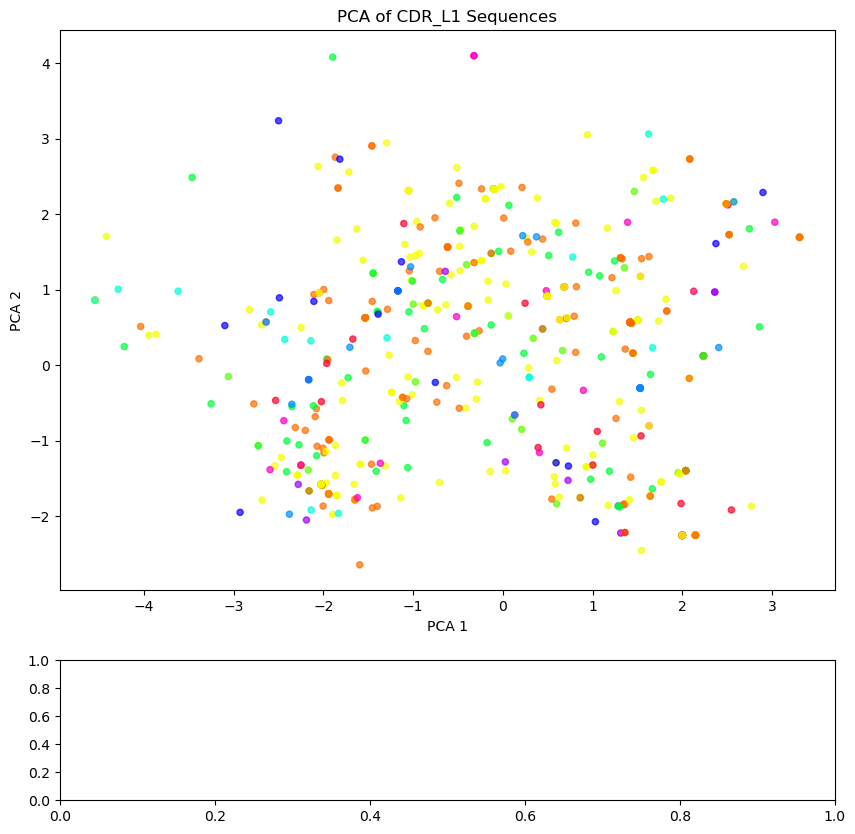

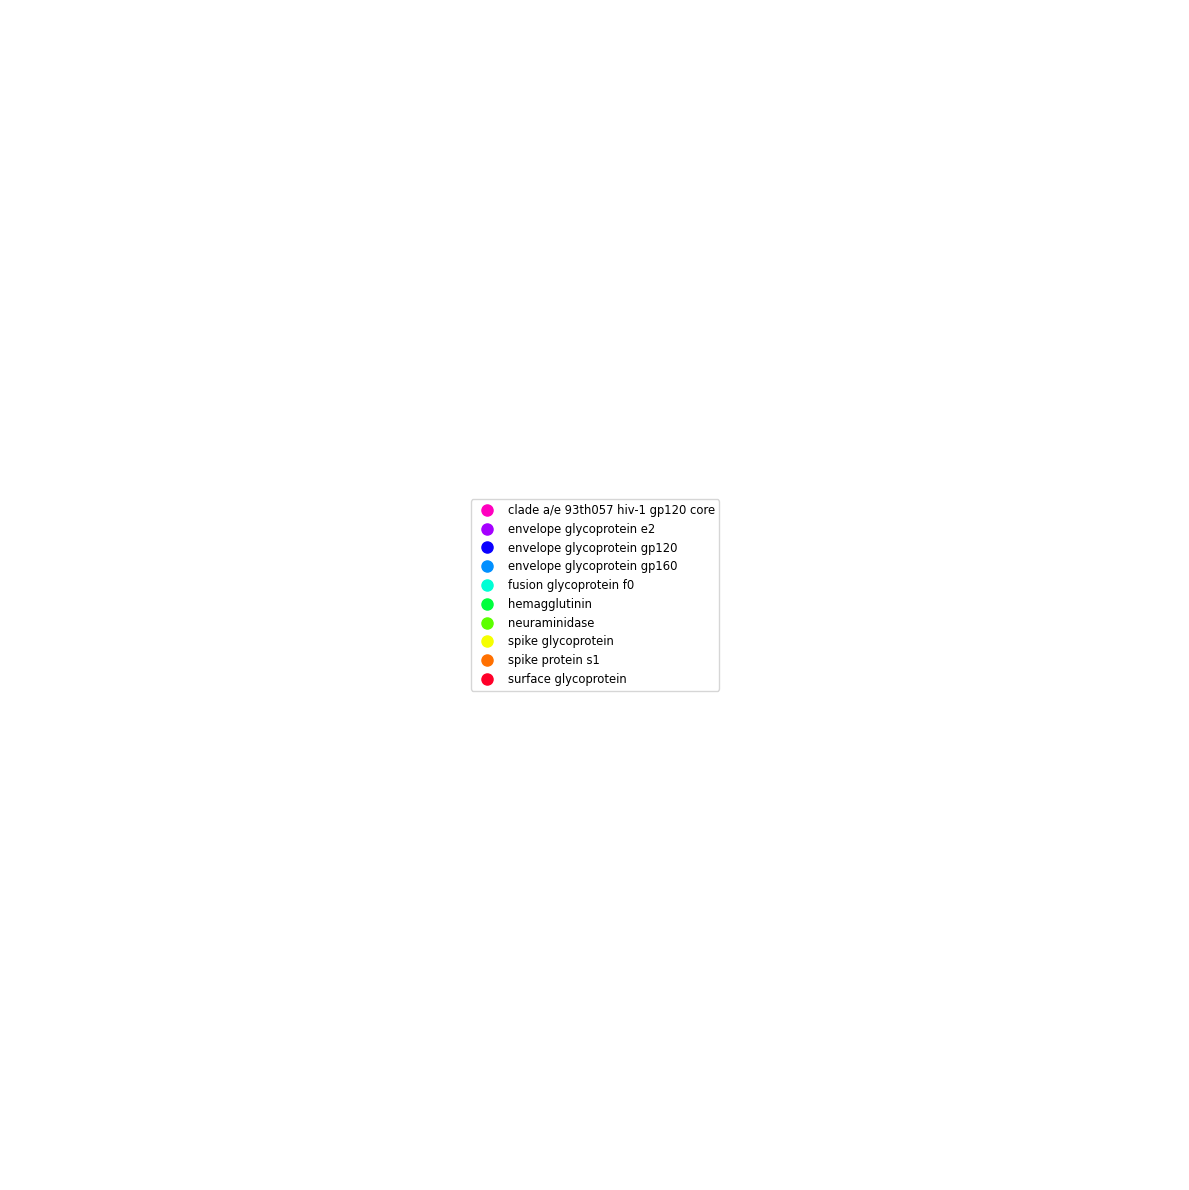

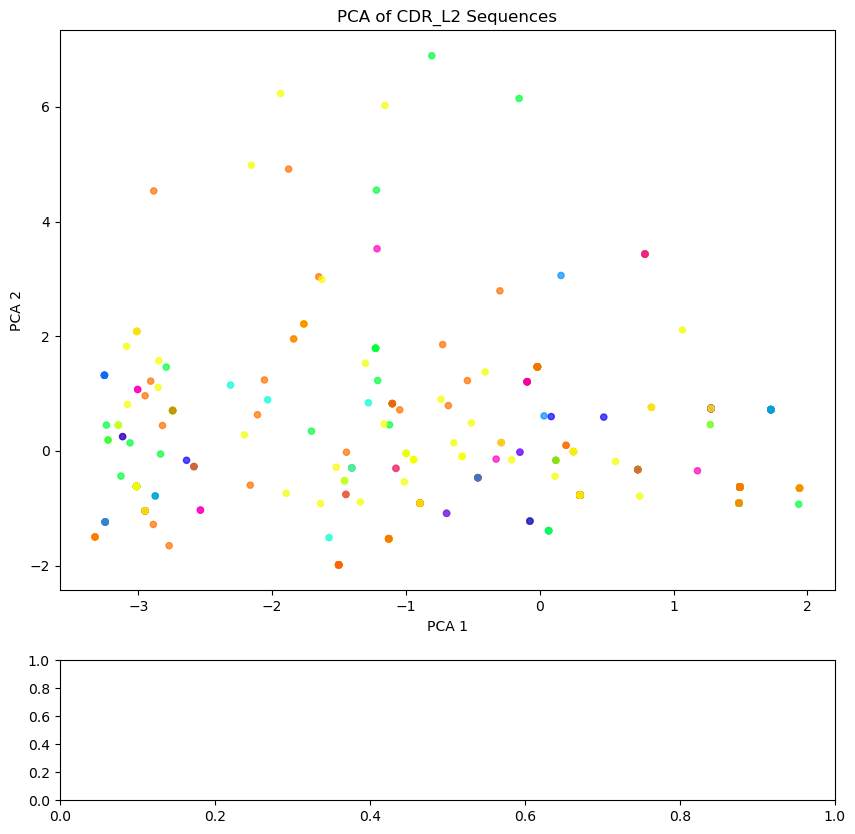

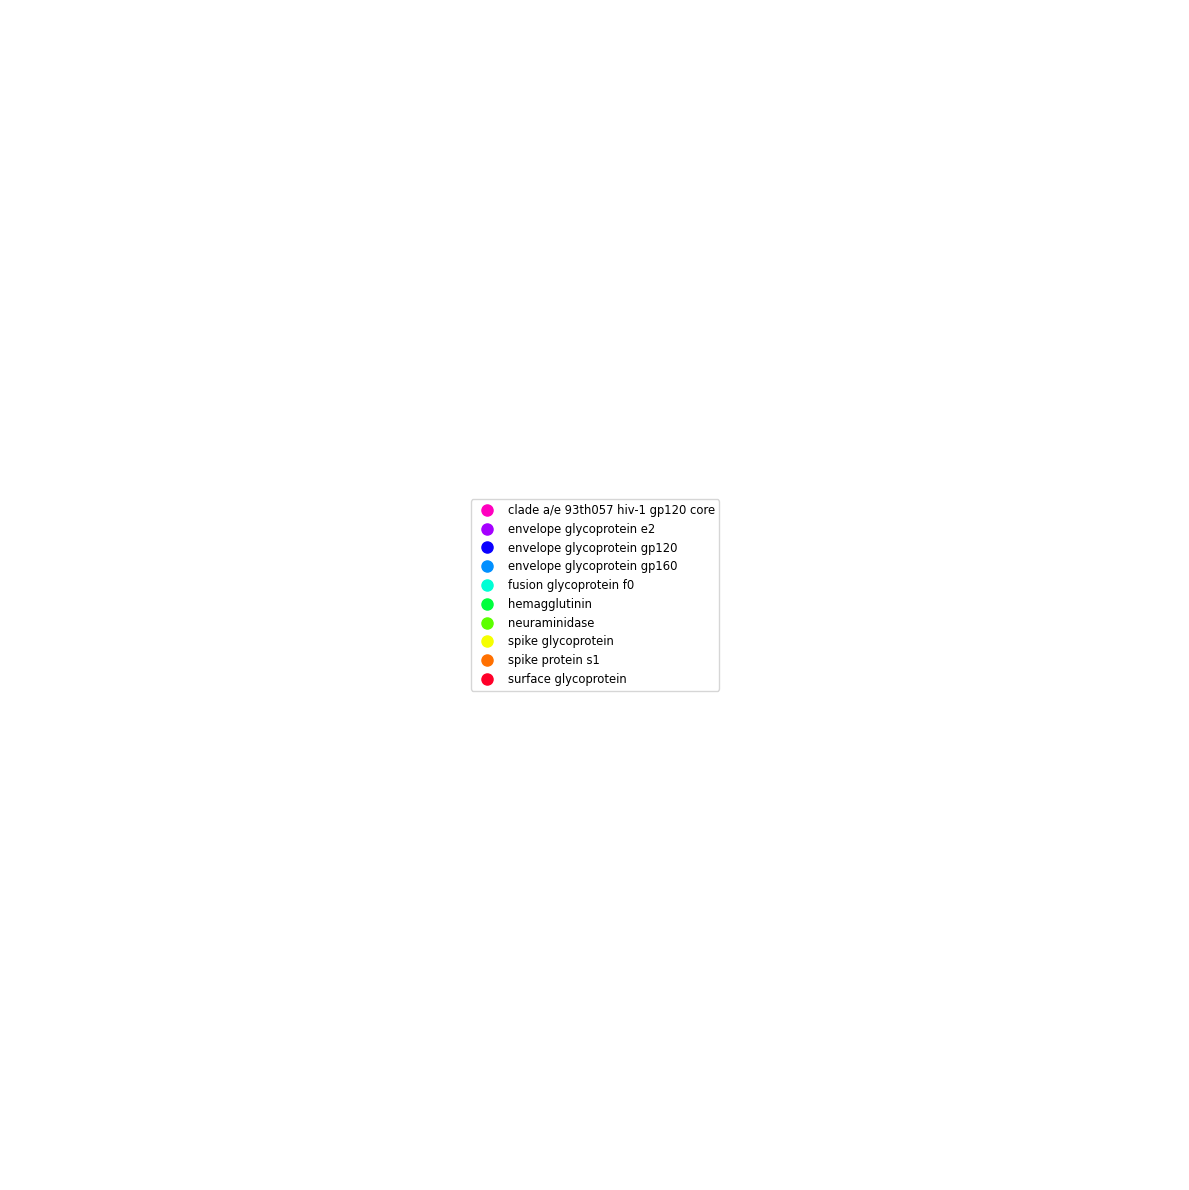

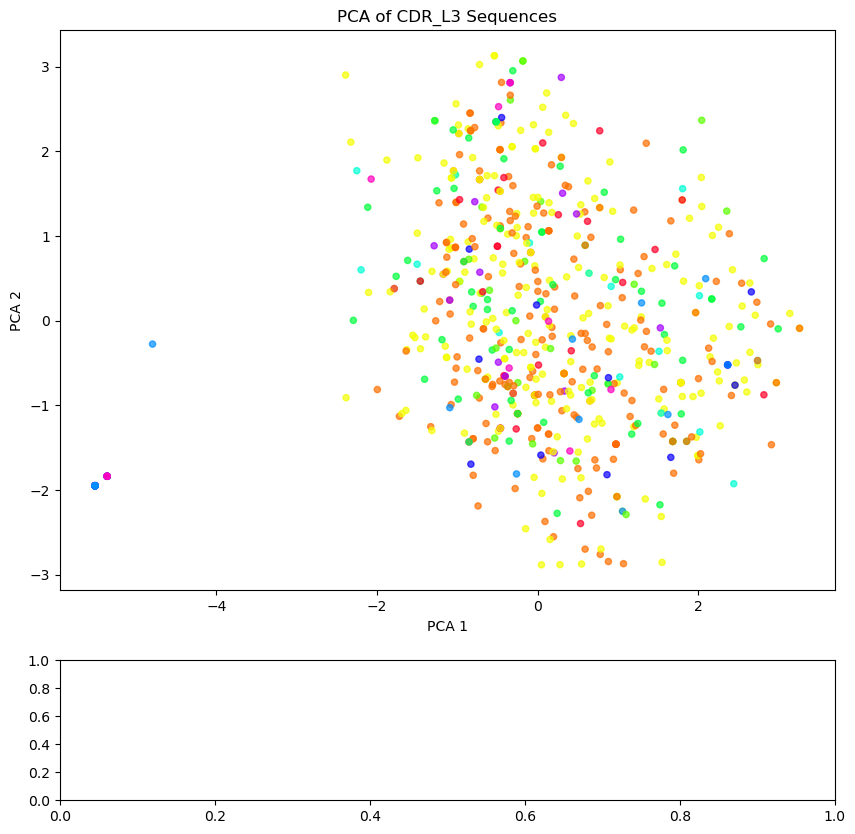

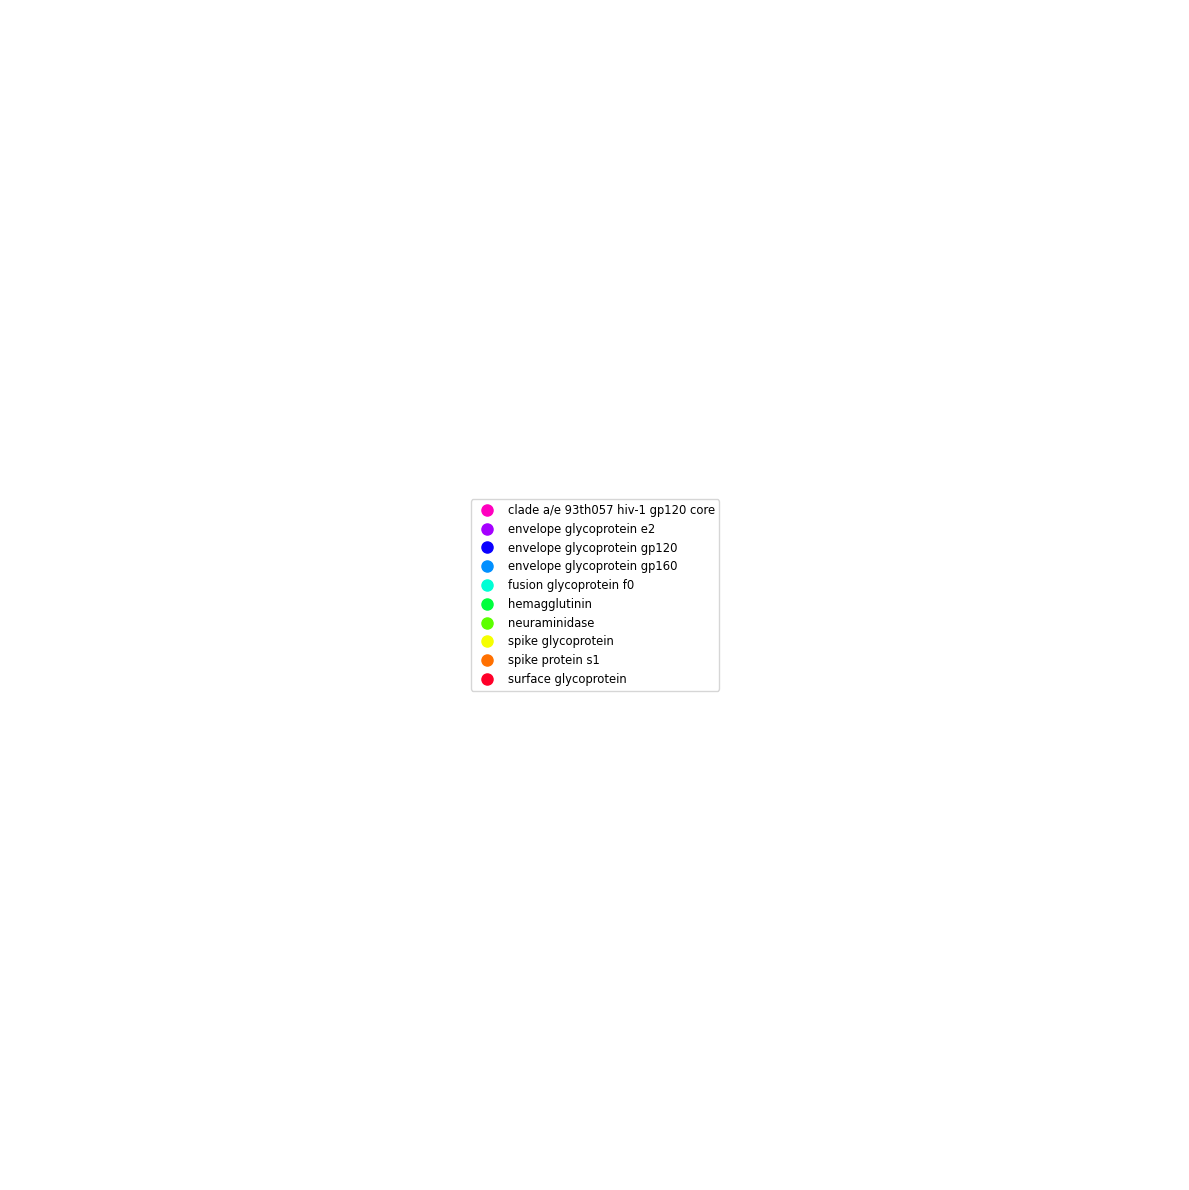

fusion glycoprotein f0: (0.0, 1.0, 0.836320191158901, 1.0)
spike glycoprotein: (0.9609609609609602, 1.0, 0.0, 1.0)
envelope glycoprotein e2: (0.6461352657004832, 0.0, 1.0, 1.0)
neuraminidase: (0.36036036036036045, 1.0, 0.0, 1.0)
hemagglutinin: (0.0, 1.0, 0.23894862604540001, 1.0)
surface glycoprotein: (1.0, 0.0, 0.16, 1.0)
clade a/e 93th057 hiv-1 gp120 core: (1.0, 0.0, 0.75, 1.0)
spike protein s1: (1.0, 0.43843843843843866, 0.0, 1.0)
envelope glycoprotein gp120: (0.04227053140096615, 0.0, 1.0, 1.0)
envelope glycoprotein gp160: (0.0, 0.5615942028985507, 1.0, 1.0)


In [6]:

for region in regions: 
    feature_space_visualize = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    show_feature_space(feature_space_visualize, region, antigen_labels)


#Überprüfung ob alle punkte mit gleichem antigen-name die gleiche farbe haben am bsp influenza a virus
idx_influenzaavirus = [i for i, a in enumerate(antigen_labels) if a == "influenza a virus"]
set([colors[i] for i in idx_influenzaavirus])

#alle farben pro antigen tabellarisch
for ant in set(antigen_labels):
    print(f"{ant}: {color_dict[ant]}")

c:\Users\marce\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Das System kann die angegebene Datei nicht finden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\marce\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\marce\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\marce\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\marce\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.C

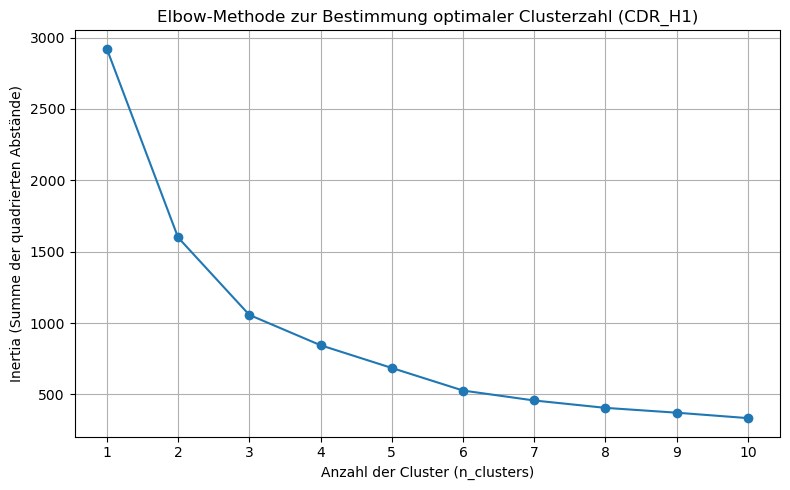

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

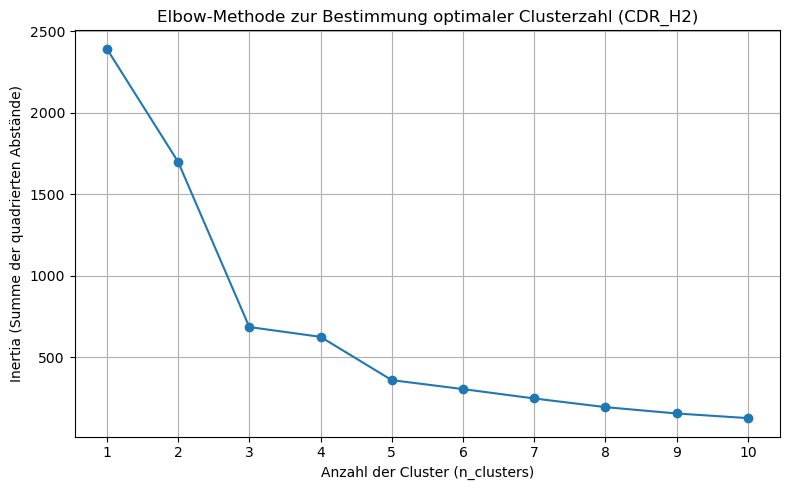

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

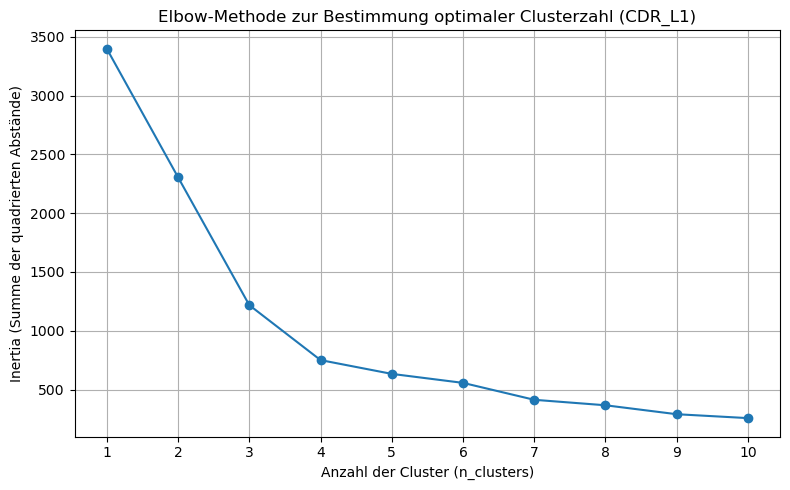

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

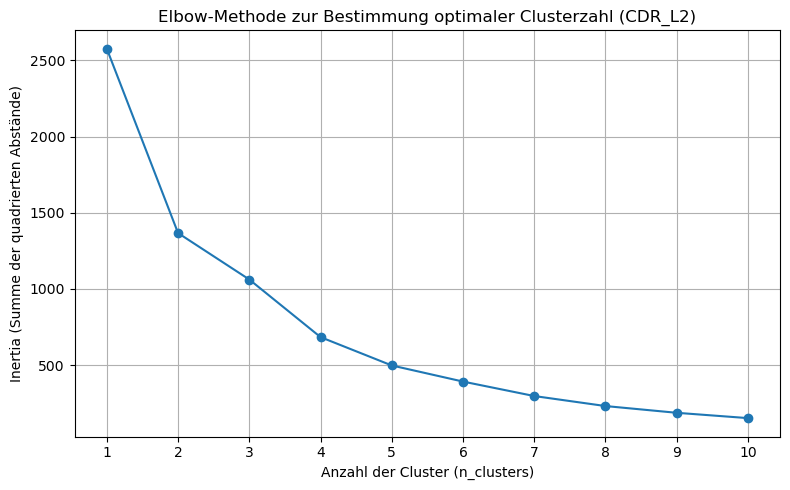

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

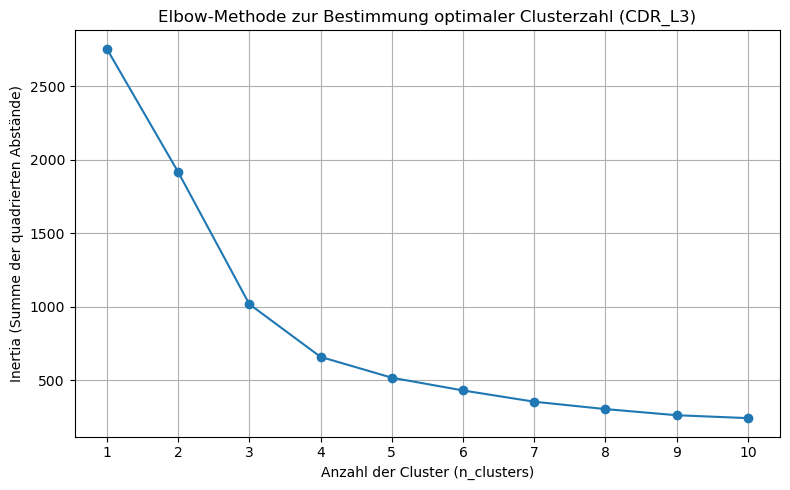

In [7]:
#elbow method 
#der erste teil ist wieder nur wdh weil der sonst die variabeln nicht findet

for region in regions:
    feature_space_elbow = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_elbow.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    #elbow method
    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


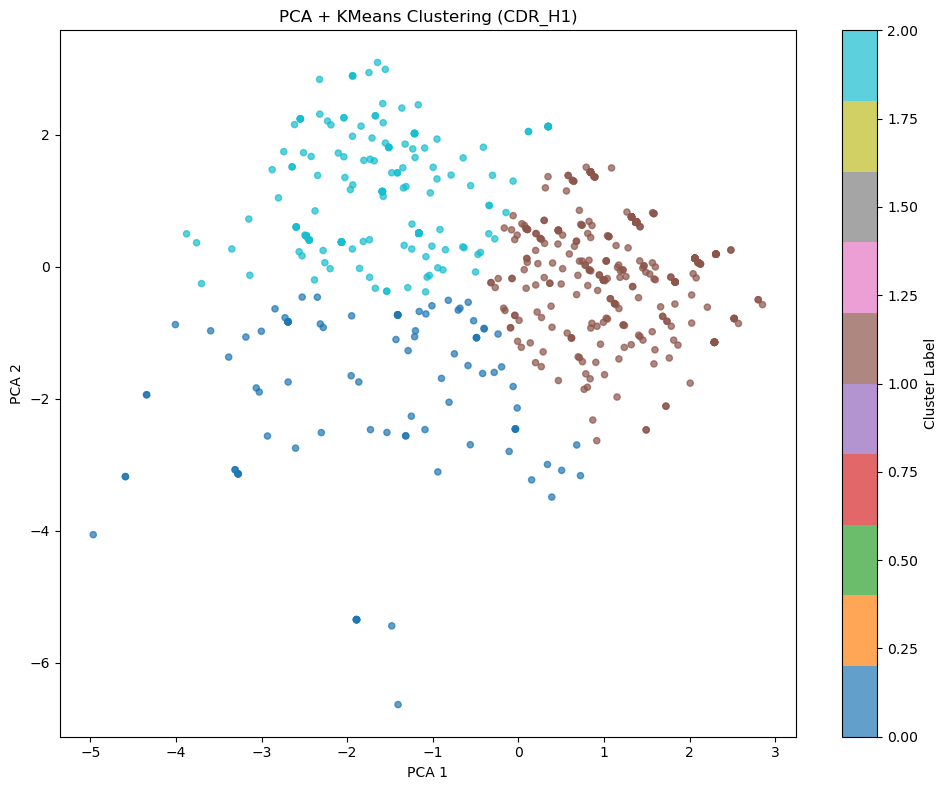


 Antigen Häufigkeiten pro Cluster für CDR_H1 

Cluster 0:
  spike glycoprotein: 31x
  spike protein s1: 28x
  envelope glycoprotein gp160: 10x
  envelope glycoprotein gp120: 8x
  hemagglutinin: 5x
  neuraminidase: 3x
  surface glycoprotein: 3x
  clade a/e 93th057 hiv-1 gp120 core: 3x
  fusion glycoprotein f0: 3x
  envelope glycoprotein e2: 3x

Cluster 1:
  spike glycoprotein: 158x
  spike protein s1: 118x
  hemagglutinin: 30x
  neuraminidase: 14x
  clade a/e 93th057 hiv-1 gp120 core: 13x
  fusion glycoprotein f0: 11x
  envelope glycoprotein e2: 9x
  surface glycoprotein: 9x
  envelope glycoprotein gp160: 8x
  envelope glycoprotein gp120: 7x

Cluster 2:
  spike protein s1: 63x
  spike glycoprotein: 52x
  hemagglutinin: 28x
  surface glycoprotein: 11x
  neuraminidase: 9x
  envelope glycoprotein e2: 5x
  envelope glycoprotein gp120: 4x
  fusion glycoprotein f0: 4x
  envelope glycoprotein gp160: 3x
  clade a/e 93th057 hiv-1 gp120 core: 2x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


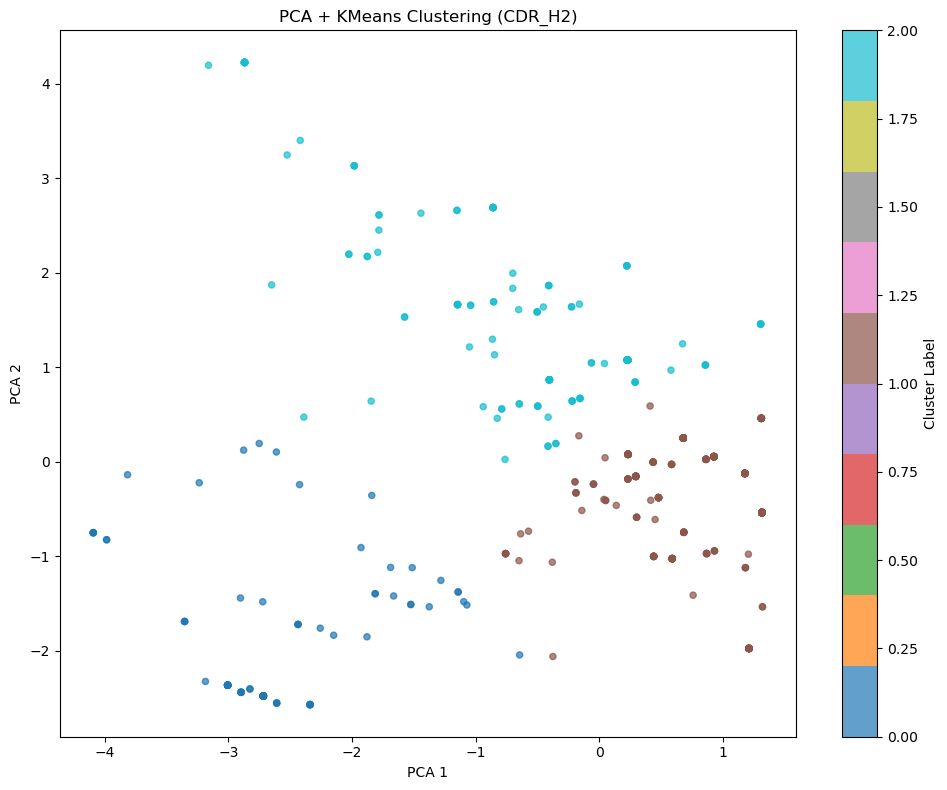


 Antigen Häufigkeiten pro Cluster für CDR_H2 

Cluster 0:
  spike glycoprotein: 30x
  spike protein s1: 18x
  envelope glycoprotein e2: 12x
  hemagglutinin: 7x
  envelope glycoprotein gp160: 6x
  envelope glycoprotein gp120: 4x
  neuraminidase: 3x
  clade a/e 93th057 hiv-1 gp120 core: 3x
  fusion glycoprotein f0: 2x
  surface glycoprotein: 1x

Cluster 1:
  spike protein s1: 128x
  spike glycoprotein: 126x
  hemagglutinin: 37x
  neuraminidase: 15x
  surface glycoprotein: 15x
  clade a/e 93th057 hiv-1 gp120 core: 12x
  envelope glycoprotein gp120: 10x
  envelope glycoprotein gp160: 9x
  fusion glycoprotein f0: 8x
  envelope glycoprotein e2: 4x

Cluster 2:
  spike glycoprotein: 85x
  spike protein s1: 63x
  hemagglutinin: 19x
  neuraminidase: 8x
  fusion glycoprotein f0: 8x
  surface glycoprotein: 7x
  envelope glycoprotein gp160: 6x
  envelope glycoprotein gp120: 5x
  clade a/e 93th057 hiv-1 gp120 core: 3x
  envelope glycoprotein e2: 1x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


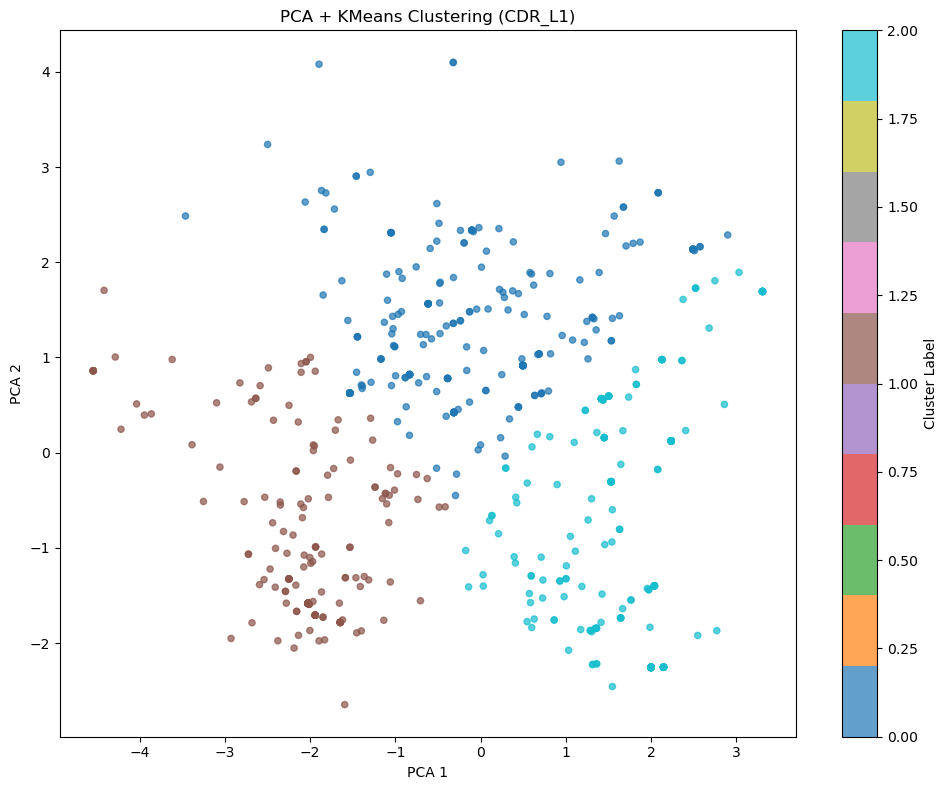


 Antigen Häufigkeiten pro Cluster für CDR_L1 

Cluster 0:
  spike glycoprotein: 95x
  spike protein s1: 77x
  hemagglutinin: 27x
  neuraminidase: 8x
  envelope glycoprotein gp120: 7x
  envelope glycoprotein gp160: 7x
  fusion glycoprotein f0: 6x
  clade a/e 93th057 hiv-1 gp120 core: 5x
  envelope glycoprotein e2: 4x
  surface glycoprotein: 3x

Cluster 1:
  spike glycoprotein: 61x
  spike protein s1: 54x
  hemagglutinin: 19x
  fusion glycoprotein f0: 9x
  envelope glycoprotein gp120: 8x
  neuraminidase: 6x
  surface glycoprotein: 6x
  envelope glycoprotein gp160: 5x
  clade a/e 93th057 hiv-1 gp120 core: 5x
  envelope glycoprotein e2: 3x

Cluster 2:
  spike glycoprotein: 85x
  spike protein s1: 78x
  hemagglutinin: 17x
  surface glycoprotein: 14x
  neuraminidase: 12x
  envelope glycoprotein e2: 10x
  envelope glycoprotein gp160: 9x
  clade a/e 93th057 hiv-1 gp120 core: 8x
  envelope glycoprotein gp120: 4x
  fusion glycoprotein f0: 3x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


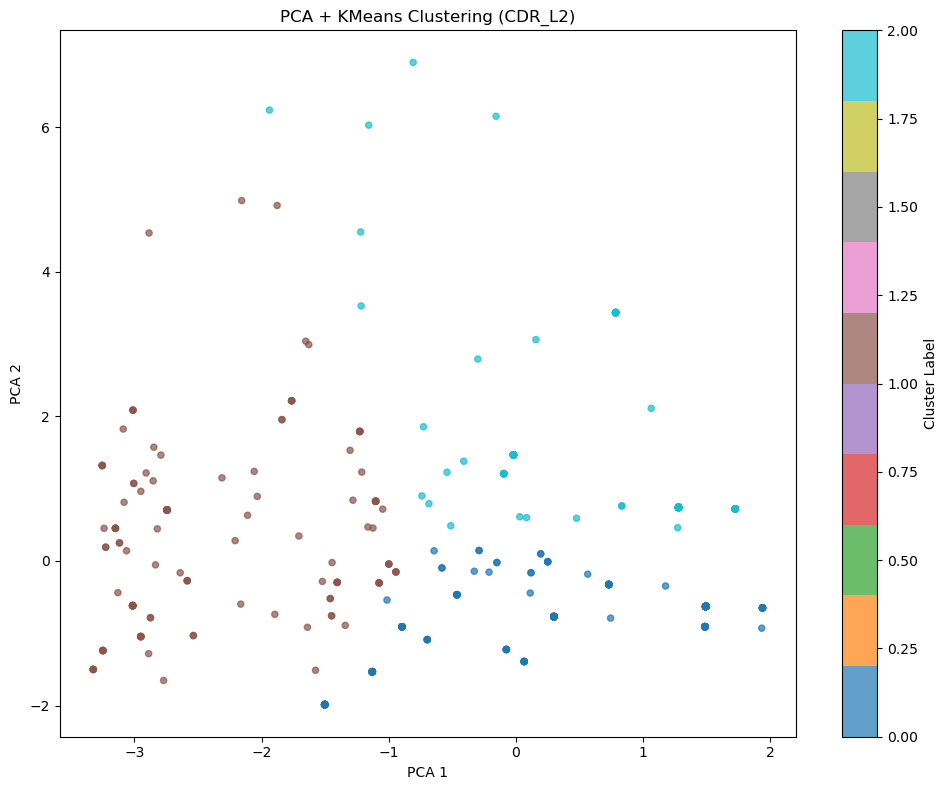


 Antigen Häufigkeiten pro Cluster für CDR_L2 

Cluster 0:
  spike glycoprotein: 127x
  spike protein s1: 116x
  hemagglutinin: 21x
  neuraminidase: 16x
  surface glycoprotein: 15x
  envelope glycoprotein e2: 8x
  fusion glycoprotein f0: 8x
  envelope glycoprotein gp120: 7x
  envelope glycoprotein gp160: 5x
  clade a/e 93th057 hiv-1 gp120 core: 5x

Cluster 1:
  spike glycoprotein: 53x
  spike protein s1: 36x
  hemagglutinin: 20x
  fusion glycoprotein f0: 9x
  envelope glycoprotein gp120: 7x
  envelope glycoprotein gp160: 5x
  clade a/e 93th057 hiv-1 gp120 core: 5x
  neuraminidase: 3x
  envelope glycoprotein e2: 2x
  surface glycoprotein: 1x

Cluster 2:
  spike glycoprotein: 61x
  spike protein s1: 57x
  hemagglutinin: 22x
  envelope glycoprotein gp160: 11x
  clade a/e 93th057 hiv-1 gp120 core: 8x
  neuraminidase: 7x
  envelope glycoprotein e2: 7x
  surface glycoprotein: 7x
  envelope glycoprotein gp120: 5x
  fusion glycoprotein f0: 1x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


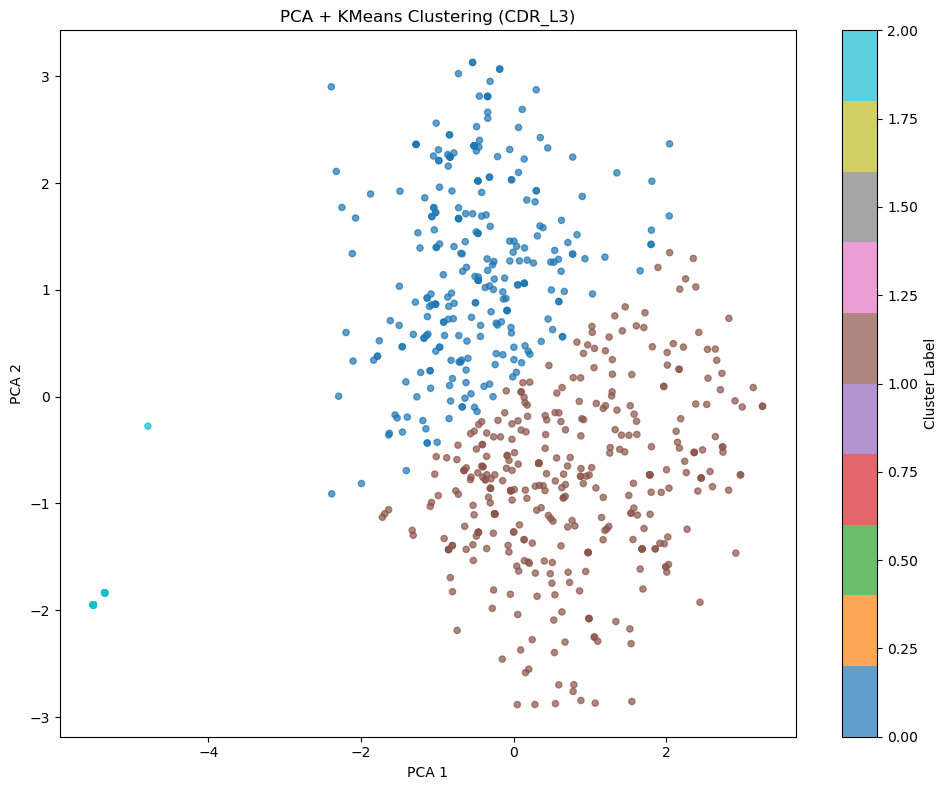


 Antigen Häufigkeiten pro Cluster für CDR_L3 

Cluster 0:
  spike glycoprotein: 105x
  spike protein s1: 86x
  hemagglutinin: 34x
  surface glycoprotein: 12x
  neuraminidase: 10x
  fusion glycoprotein f0: 10x
  envelope glycoprotein e2: 8x
  clade a/e 93th057 hiv-1 gp120 core: 5x
  envelope glycoprotein gp120: 3x
  envelope glycoprotein gp160: 1x

Cluster 1:
  spike glycoprotein: 136x
  spike protein s1: 123x
  hemagglutinin: 29x
  neuraminidase: 16x
  surface glycoprotein: 11x
  envelope glycoprotein gp120: 10x
  envelope glycoprotein e2: 9x
  envelope glycoprotein gp160: 9x
  fusion glycoprotein f0: 8x
  clade a/e 93th057 hiv-1 gp120 core: 5x

Cluster 2:
  envelope glycoprotein gp160: 11x
  clade a/e 93th057 hiv-1 gp120 core: 8x
  envelope glycoprotein gp120: 6x


In [8]:
# Clustering auf basis der PCA
#kmeans mit 3 => laut elbow method am sinnvollsten

 # Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen:
for region in regions:
    feature_space_kmeans = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    
    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_kmeans.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=3, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")


In [9]:
# Hierarchisches Clustering und Identifikation der farbigen Teilbäume



# CDR-Spalten & Antigen-Spalte
cdr_columns = ['CDR_H1','CDR_H2','CDR_H3','CDR_L1','CDR_L2','CDR_L3']
antigen_col = "antigen_name"

# Wie viele Fusionen vom Wurzelknoten wir runterscrollen wollen
levels_down = 8   # z.B. 8 Ebenen

# Daten einlesen & unvollständige Zeilen entfernen
# zweite Zeile überflüssig, wenn Marcel data clean up korrekt gemacht hat
df = pd.read_csv("data/df.tsv", sep='\t')
df = df.dropna(subset=cdr_columns + [antigen_col]).reset_index(drop=True)


# AA-Häufigkeitsvektor-Funktion (20 Standard-AAs)
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")
def aa_freq_vector(seq: str) -> np.ndarray:   #aa_freq_vector name der Funktion, nimmt eine sequenz, die string sein soll, rückgabe ist np.ndarray (Vektor)
    L      = len(seq)                                                   # Sequenzlänge 
    counts = np.array([seq.count(aa) for aa in AA_LIST], dtype=float)   # Häufigkeit jeder AS
    return counts / L                                                    # direkte Normierung


#Loop über jede CDR-Region
for cdr in cdr_columns:
    seqs = df[cdr].tolist() #alle sequenzen als strings
    X    = np.vstack([aa_freq_vector(s) for s in seqs]) #für jede Sequenz 20 dimensionaler Häufigkeitsvektor, als Matrix zusammengeführt

    # Linkage berechnen (Ward, euklidische Distanz)
    Z = linkage(X, method="ward", metric="euclidean") #erstellt aus feature matrix X die linkage Matrix Z
                #ward minimiert varianz innerhalb der Cluster bei jedem merge

    # Threshold-Distanz für levels_down Stufen
    threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0
            # Z.shape[0] ist Anzahl aller merge schritte (n-1 für sequenzen)
            # Z[-levels_down,2] Distanz des Merge_schrittes der Plätze von unten


    # Erzeuge das Dendrogramm im "no_plot"-Modus, um Farben der Blätter abzufragen
    ddata = dendrogram(
        Z,
        labels=[str(i) for i in range(len(seqs))],
        color_threshold=threshold,
        no_plot=True       # unterdrückt die Grafik, liefert aber in ddata alle nötigen Infos
    )

    # Verbindet Blatt indizes mit Farbe
    leaves           = ddata['leaves']            # Reihenfolge der Blatt-Indizes
    leaves_colors    = ddata['leaves_color_list'] # RGB-Farben pro Blatt, gemäß threshold
    leaf_color_map   = {leaf: col for leaf, col in zip(leaves, leaves_colors)}
                    # zip leaves verbindet blatt_indizes mit jeweiliger Farbe
                    # leaf: baut ein dict, indem der Blatt_index(leaves) und das entsprechende RGB-Farb-Tuple (col) ist

    

    #Hier nochmal genau den Code nachvollziehen
    # 10) Finde die eindeutigen Farben in der Reihenfolge ihres Auftretens
    unique_colors = [] #ist Liste aller verschieder RGB-Farben, die in Dendrogramm auftauchen
    for col in leaves_colors:
        if col not in unique_colors:
            unique_colors.append(col) #Lister aller verschiedenen Farben, wie sie auftauchen, in gleicher Reihenfolge

    


    #  Weise jeder Farbe eine Cluster-Nummer zu
    color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}
   
    # 12) Cluster-Zuordnung für jedes Blatt nach Farbe
    cluster_ids = {leaf: color_cluster_map[col] for leaf, col in leaf_color_map.items()}

    # 13) Plot des vollständigen Dendrogramms mit Farb-Schwellenwert
    plt.figure(figsize=(8, 6))
    dendrogram(
        Z,
        labels=[str(i) for i in range(len(seqs))],
        color_threshold=threshold,  # färbt die Haupt-Branches
        leaf_rotation=0,
        leaf_font_size=6
    )
    plt.title(f"Dendrogramm (cut → {levels_down} Ebenen): {cdr}")
    plt.xlabel("Distance")
    plt.tight_layout()
    plt.show()

    # 14) Ausgabe: für jeden farbigen Teilbaum die Antigen-Häufigkeiten
    print(f"\nTeilbaum-Aufteilung für {cdr} (cut auf {levels_down} Ebenen → {len(unique_colors)} Teilbäume):")
    for col in unique_colors:
        cid     = color_cluster_map[col]
        # alle Blätter, deren Farbe = col
        leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
        # Antigen-Namen der entsprechenden Zeilen
        hits    = df.loc[leaves_in_cluster, antigen_col]
        counts  = hits.value_counts()
        print(f"\nTeilbaum {cid}:")
        for antigen, cnt in counts.items():
            print(f"  {antigen}: {cnt}×")


KeyError: ['CDR_H3']

In [ ]:

#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären



 Kontingenztabelle für CDR_H1
Cluster                                               0    1   2
Antigen                                                         
envelope glycoprotein gp120                          26   14   0
envelope glycoprotein gp160                          19   34   0
fusion glycoprotein f0                                8   13   0
guanine nucleotide-binding protein g(i) subunit...    0    0  77
hemagglutinin                                        35   26   3
hemagglutinin | hemagglutinin                        16    8   0
neuraminidase                                        26    9   0
spike glycoprotein                                  239  107   1
spike protein s1                                    226   87   5
surface glycoprotein                                 29    4   0

 Chi-Quadrat-Test Ergebnis für CDR_H1
Chi2-Wert: 949.0685
p-Wert:    5.3014e-190
Freiheitsgrade: 18

Erwartete Häufigkeiten (unter Nullhypothese):
Cluster                                  